# Notebook 04 : Prédiction des Ventes 

**PFE 2026 - Malek - ESB**

## Objectifs

Construire un modèle de **Machine Learning supervisé** capable de 
**PRÉDIRE le nombre de ventes** d'un vendeur en comparant 
**7 algorithmes** différents.

## Algorithmes comparés

### Modèles linéaires
1. **Régression linéaire** : baseline simple

### Modèles à proximité
2. **KNN (K-Nearest Neighbors)** avec **GridSearchCV** 

### Modèles à kernel
3. **SVM (Support Vector Machine)** Regressor

### Modèles à arbres
4. **Decision Tree** Regressor
5. **Random Forest** Regressor

### Modèles ensemble
6. **XGBoost** (le plus performant)

### Deep Learning
7. **ANN (Artificial Neural Network)** TensorFlow

## Métriques d'évaluation

- **R²** : variance expliquée (max = 1)
- **MAE** : erreur absolue moyenne
- **RMSE** : erreur quadratique moyenne
- **Temps** : performance en secondes

## Démarche scientifique

1. Préparation des features
2. Train/Test split (80/20)
3. Entraînement des 7 modèles
4. Optimisation hyperparamètres (GridSearchCV pour KNN)
5. Comparaison rigoureuse
6. Sélection du meilleur modèle

In [1]:
# === IMPORTS COMPLETS ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from pathlib import Path
from dotenv import load_dotenv
import os
import time

# Machine Learning - sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Algorithmes
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# XGBoost
import xgboost as xgb

# TensorFlow pour ANN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings('ignore')

# Configuration
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# Couleurs pour les 7 algos
COLORS = {
    'LR': '#1f77b4',
    'KNN': '#ff7f0e',
    'SVM': '#2ca02c',
    'DT': '#d62728',
    'RF': '#9467bd',
    'XGB': '#FF6600',
    'ANN': '#17becf'
}

# Reproductibilite
np.random.seed(42)
tf.random.set_seed(42)

print("Bibliotheques chargees !")
print(f"sklearn : {__import__('sklearn').__version__}")
print(f"xgboost : {xgb.__version__}")
print(f"tensorflow : {tf.__version__}")

Bibliotheques chargees !
sklearn : 1.7.2
xgboost : 3.2.0
tensorflow : 2.21.0


In [2]:
# === CONNEXION POSTGRESQL ===

PROJECT_ROOT = Path.cwd().parent
load_dotenv(PROJECT_ROOT / ".env")

DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME", "orange_dwh")
DB_USER = os.getenv("DB_USER", "postgres")
DB_PASSWORD = os.getenv("DB_PASSWORD", "")

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

with engine.connect() as conn:
    result = conn.execute(text("SELECT 1")).fetchone()
print(f"Connexion OK : {result}")

Connexion OK : (1,)


## 1. Chargement et préparation des données

In [3]:
# === CHARGEMENT DES DONNEES ===

query = """
SELECT 
    v.seller_id    AS code,
    v.seller_name  AS vendeur,
    b.canal_vente  AS canal,
    b.entity_name  AS boutique,
    b.region       AS region,
    COUNT(*)       AS nb_ventes
FROM fact_ventes f
JOIN dim_vendeur v ON f.vendeur_key = v.vendeur_key
JOIN dim_boutique b ON f.boutique_key = b.boutique_key
GROUP BY v.seller_id, v.seller_name, b.canal_vente, b.entity_name, b.region
HAVING COUNT(*) > 0;
"""

df = pd.read_sql(query, engine)

print(f"Nombre de vendeurs : {len(df):,}")
print(f"Dimensions : {df.shape}")
df.head()

Nombre de vendeurs : 1,426
Dimensions : (1426, 6)


,code,vendeur,canal,boutique,region,nb_ventes
0,AABDKRIM,Abdelkarim Aldoun,FRANCHISE,Franchise Jerba Midoun,None,17
1,AABOUDI_EXT,AYOUB ABOUDI,LAB2.0,LAB AYOUB GSM,None,353
2,AAISSAOUI_EXT,AYMEN AISSAOUI,FRANCHISE,Franchise Kram,None,183
3,AAKREMI2_EXT,AMAL AKREMI2,LAB2.0,LAB2.0 MOBISHOP,None,95
4,AALDOUN_EXT,ABDELKARIM ALDOUN,FRANCHISE,Franchise Jerba Midoun,None,5


In [4]:
# === PREPARATION DES FEATURES ===

# Remplir valeurs manquantes
df = df.fillna('Non specifie')

# Variables explicatives
features_cat = ['canal', 'boutique', 'region']
target = 'nb_ventes'

# Encoder les variables categorielles
encoders = {}
df_encoded = df.copy()

for col in features_cat:
    le = LabelEncoder()
    df_encoded[col + '_encoded'] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

# Selection finale
features_final = [col + '_encoded' for col in features_cat]
X = df_encoded[features_final].values
y = df_encoded[target].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardisation pour les algos qui le necessitent
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Features : {features_final}")
print(f"Cible : {target}")
print(f"\nTrain : {X_train.shape[0]:,} vendeurs")
print(f"Test  : {X_test.shape[0]:,} vendeurs")

Features : ['canal_encoded', 'boutique_encoded', 'region_encoded']
Cible : nb_ventes

Train : 1,140 vendeurs
Test  : 286 vendeurs


## 2. Préparation du tableau comparatif

Nous allons stocker les résultats de chaque algorithme pour comparaison.

In [5]:
# === STRUCTURE POUR STOCKER LES RESULTATS ===

results = []

def evaluate_model(name, y_true, y_pred, training_time):
    """Calcule et stocke les metriques d'un modele."""
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    results.append({
        'Algorithme': name,
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse,
        'Temps_s': training_time
    })
    
    print(f"\n>> {name}")
    print(f"   R2     : {r2:.4f} ({r2*100:.1f}%)")
    print(f"   MAE    : {mae:.2f} ventes")
    print(f"   RMSE   : {rmse:.2f} ventes")
    print(f"   Temps  : {training_time:.2f}s")
    
    return r2, mae, rmse

print("Structure de comparaison prete !")

Structure de comparaison prete !


## 3. Algorithme 1 : Régression Linéaire (Baseline)

In [6]:
# === 1. REGRESSION LINEAIRE ===

print("Entrainement Regression Lineaire...")

start = time.time()
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
elapsed = time.time() - start

evaluate_model('Regression Lineaire', y_test, y_pred_lr, elapsed)

Entrainement Regression Lineaire...

>> Regression Lineaire
   R2     : 0.0238 (2.4%)
   MAE    : 34.11 ventes
   RMSE   : 47.44 ventes
   Temps  : 0.05s


(0.023764751630806158, 34.11139523050066, np.float64(47.44142202828069))

## 4. Algorithme 2 : KNN avec GridSearchCV 

**GridSearchCV** teste plusieurs valeurs de k (3, 5, 7, 9, 11) 
pour trouver le **k optimal** automatiquement.

In [7]:
# === 2. KNN AVEC GRIDSEARCHCV ===

print("Entrainement KNN avec GridSearchCV...")
print("Recherche du k optimal entre 3 et 11...")

start = time.time()

# Hyperparametres a tester
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance']
}

# GridSearch
grid_knn = GridSearchCV(
    KNeighborsRegressor(),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_knn.fit(X_train_scaled, y_train)
y_pred_knn = grid_knn.predict(X_test_scaled)

elapsed = time.time() - start

print(f"\nMeilleurs hyperparametres : {grid_knn.best_params_}")
print(f"Meilleur score CV : {grid_knn.best_score_:.4f}")

evaluate_model('KNN (GridSearch)', y_test, y_pred_knn, elapsed)

Entrainement KNN avec GridSearchCV...
Recherche du k optimal entre 3 et 11...

Meilleurs hyperparametres : {'n_neighbors': 11, 'weights': 'uniform'}
Meilleur score CV : 0.0891

>> KNN (GridSearch)
   R2     : 0.1406 (14.1%)
   MAE    : 32.65 ventes
   RMSE   : 44.51 ventes
   Temps  : 4.49s


(0.1405821958645891, 32.64685314685315, np.float64(44.51256586526823))

## 5. Algorithme 3 : SVM Regressor

In [8]:
# === 3. SVM REGRESSOR ===

print("Entrainement SVM Regressor...")
print("(peut prendre 1-2 minutes sur grands datasets)")

start = time.time()
svm = SVR(kernel='rbf', C=1.0, gamma='scale')
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
elapsed = time.time() - start

evaluate_model('SVM (RBF)', y_test, y_pred_svm, elapsed)

Entrainement SVM Regressor...
(peut prendre 1-2 minutes sur grands datasets)

>> SVM (RBF)
   R2     : -0.0501 (-5.0%)
   MAE    : 32.08 ventes
   RMSE   : 49.20 ventes
   Temps  : 0.20s


(-0.05014376356268979, 32.082377878090384, np.float64(49.20450134193646))

## 6. Algorithme 4 : Decision Tree

In [9]:
# === 4. DECISION TREE ===

print("Entrainement Decision Tree...")

start = time.time()
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
elapsed = time.time() - start

evaluate_model('Decision Tree', y_test, y_pred_dt, elapsed)

Entrainement Decision Tree...

>> Decision Tree
   R2     : 0.0879 (8.8%)
   MAE    : 33.21 ventes
   RMSE   : 45.86 ventes
   Temps  : 0.01s


(0.08791905778890241, 33.212810990942415, np.float64(45.856103263633884))

## 7. Algorithme 5 : Random Forest

In [10]:
# === 5. RANDOM FOREST ===

print("Entrainement Random Forest...")

start = time.time()
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
elapsed = time.time() - start

evaluate_model('Random Forest', y_test, y_pred_rf, elapsed)

Entrainement Random Forest...

>> Random Forest
   R2     : 0.1271 (12.7%)
   MAE    : 32.92 ventes
   RMSE   : 44.86 ventes
   Temps  : 0.36s


(0.12711971207504014, 32.91838770586251, np.float64(44.8598481394454))

## 8. Algorithme 6 : XGBoost 

In [11]:
# === 6. XGBOOST ===

print("Entrainement XGBoost...")

start = time.time()
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
elapsed = time.time() - start

evaluate_model('XGBoost', y_test, y_pred_xgb, elapsed)

Entrainement XGBoost...

>> XGBoost
   R2     : 0.0723 (7.2%)
   MAE    : 33.34 ventes
   RMSE   : 46.25 ventes
   Temps  : 2.22s


(0.07232487201690674, 33.342185974121094, np.float64(46.246452566656394))

## 9. Algorithme 7 : ANN (TensorFlow/Keras)

**Architecture** : 3 couches denses avec dropout
- Input → 64 → Dropout → 32 → Dropout → Output

Entrainement ANN (TensorFlow)...
Cela peut prendre 1-2 minutes...

>> ANN (Deep Learning)
   R2     : 0.0682 (6.8%)
   MAE    : 33.40 ventes
   RMSE   : 46.35 ventes
   Temps  : 19.54s


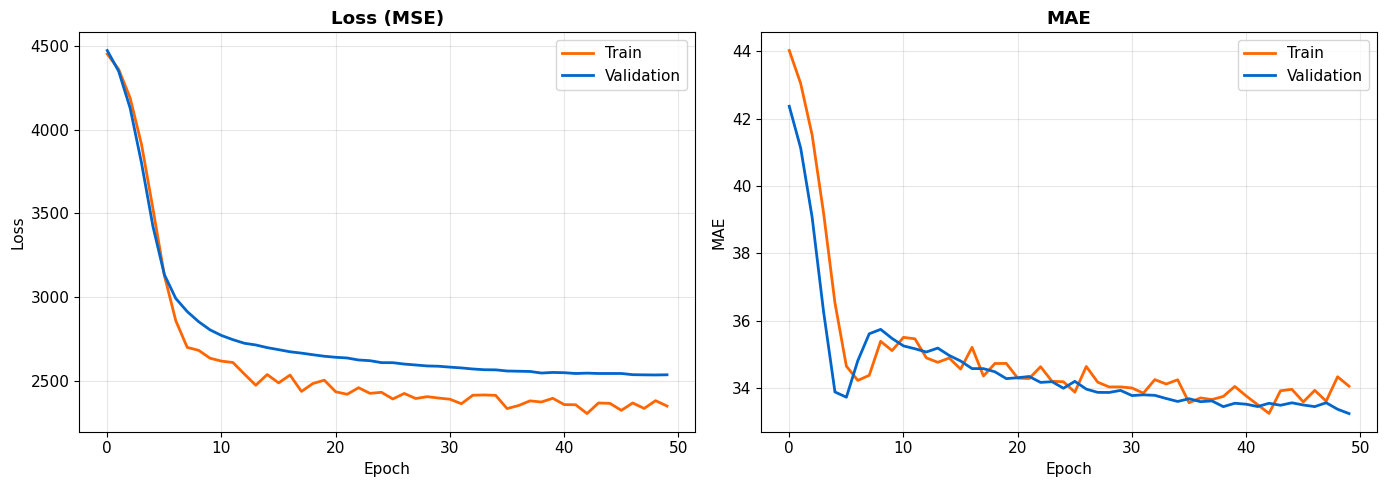

In [14]:
# === 7. ANN (Artificial Neural Network) ===

print("Entrainement ANN (TensorFlow)...")
print("Cela peut prendre 1-2 minutes...")

start = time.time()

# Architecture
ann = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1)  # Sortie : 1 valeur (regression)
])

ann.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Entrainement
history = ann.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# Predictions
y_pred_ann = ann.predict(X_test_scaled, verbose=0).flatten()

elapsed = time.time() - start

evaluate_model('ANN (Deep Learning)', y_test, y_pred_ann, elapsed)

# Couleurs
COLOR_ORANGE = '#FF6600'
COLOR_BLUE = '#0066CC'

# Historique
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], color=COLOR_ORANGE, label='Train', linewidth=2)
axes[0].plot(history.history['val_loss'], color=COLOR_BLUE, label='Validation', linewidth=2)
axes[0].set_title('Loss (MSE)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# MAE
axes[1].plot(history.history['mae'], color=COLOR_ORANGE, label='Train', linewidth=2)
axes[1].plot(history.history['val_mae'], color=COLOR_BLUE, label='Validation', linewidth=2)
axes[1].set_title('MAE', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Comparaison FINALE des 7 algorithmes

In [15]:
# === TABLEAU COMPARATIF FINAL ===

df_results = pd.DataFrame(results)
df_results = df_results.sort_values('R2', ascending=False).reset_index(drop=True)

# Ajouter le rang
df_results.insert(0, 'Rang', range(1, len(df_results) + 1))

# Marquer le meilleur
df_results['Choix'] = ''
df_results.loc[0, 'Choix'] = 'RETENU (TOP)'
df_results.loc[df_results['Algorithme'] == 'Regression Lineaire', 'Choix'] = 'Baseline'

print("CLASSEMENT FINAL DES 7 ALGORITHMES")
print("=" * 80)
print(df_results.to_string(index=False))

print(f"\nMEILLEUR ALGORITHME : {df_results.iloc[0]['Algorithme']}")
print(f"  - R2     : {df_results.iloc[0]['R2']:.4f} ({df_results.iloc[0]['R2']*100:.1f}%)")
print(f"  - MAE    : {df_results.iloc[0]['MAE']:.2f}")
print(f"  - RMSE   : {df_results.iloc[0]['RMSE']:.2f}")
print(f"  - Temps  : {df_results.iloc[0]['Temps_s']:.2f}s")

CLASSEMENT FINAL DES 7 ALGORITHMES
 Rang          Algorithme        R2       MAE      RMSE   Temps_s        Choix
    1    KNN (GridSearch)  0.140582 32.646853 44.512566  4.485815 RETENU (TOP)
    2       Random Forest  0.127120 32.918388 44.859848  0.358829             
    3       Decision Tree  0.087919 33.212811 45.856103  0.006213             
    4             XGBoost  0.072325 33.342186 46.246453  2.215505             
    5 ANN (Deep Learning)  0.068231 33.404720 46.348375 19.538731             
    6 Regression Lineaire  0.023765 34.111395 47.441422  0.045233     Baseline
    7           SVM (RBF) -0.050144 32.082378 49.204501  0.201638             

MEILLEUR ALGORITHME : KNN (GridSearch)
  - R2     : 0.1406 (14.1%)
  - MAE    : 32.65
  - RMSE   : 44.51
  - Temps  : 4.49s


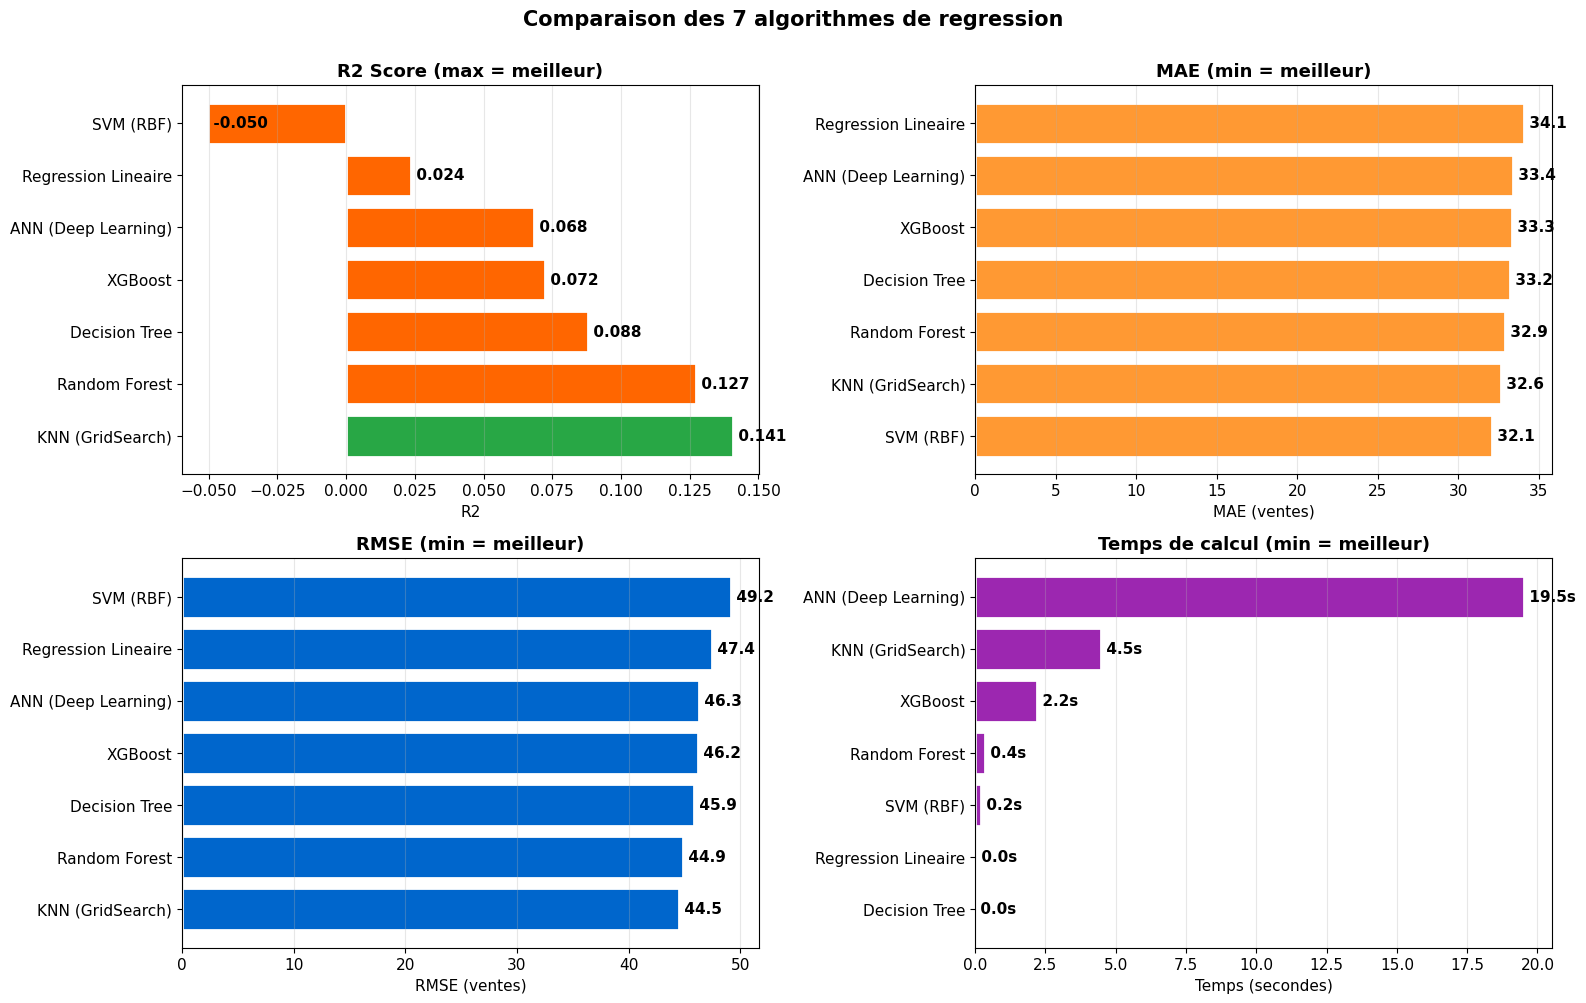

In [17]:
# === VISUALISATION COMPARATIVE ===

# Definir les couleurs ICI (au cas ou)
COLOR_ORANGE = '#FF6600'
COLOR_GREEN = '#28A745'
COLOR_BLUE = '#0066CC'
COLOR_PURPLE = '#9C27B0'
COLOR_LIGHT_ORANGE = '#FF9933'

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. R2 Score (max = meilleur)
colors_r2 = [COLOR_GREEN if i == 0 else COLOR_ORANGE for i in range(len(df_results))]
axes[0, 0].barh(df_results['Algorithme'], df_results['R2'],
                color=colors_r2,
                edgecolor='white', linewidth=2)
for i, val in enumerate(df_results['R2']):
    axes[0, 0].text(val, i, f' {val:.3f}', va='center', fontweight='bold')
axes[0, 0].set_title('R2 Score (max = meilleur)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('R2')
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. MAE (min = meilleur)
df_sorted_mae = df_results.sort_values('MAE')
axes[0, 1].barh(df_sorted_mae['Algorithme'], df_sorted_mae['MAE'],
                color=COLOR_LIGHT_ORANGE, edgecolor='white', linewidth=2)
for i, val in enumerate(df_sorted_mae['MAE']):
    axes[0, 1].text(val, i, f' {val:.1f}', va='center', fontweight='bold')
axes[0, 1].set_title('MAE (min = meilleur)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('MAE (ventes)')
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. RMSE (min = meilleur)
df_sorted_rmse = df_results.sort_values('RMSE')
axes[1, 0].barh(df_sorted_rmse['Algorithme'], df_sorted_rmse['RMSE'],
                color=COLOR_BLUE, edgecolor='white', linewidth=2)
for i, val in enumerate(df_sorted_rmse['RMSE']):
    axes[1, 0].text(val, i, f' {val:.1f}', va='center', fontweight='bold')
axes[1, 0].set_title('RMSE (min = meilleur)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('RMSE (ventes)')
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Temps (min = meilleur)
df_sorted_time = df_results.sort_values('Temps_s')
axes[1, 1].barh(df_sorted_time['Algorithme'], df_sorted_time['Temps_s'],
                color=COLOR_PURPLE, edgecolor='white', linewidth=2)
for i, val in enumerate(df_sorted_time['Temps_s']):
    axes[1, 1].text(val, i, f' {val:.1f}s', va='center', fontweight='bold')
axes[1, 1].set_title('Temps de calcul (min = meilleur)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Temps (secondes)')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.suptitle('Comparaison des 7 algorithmes de regression', 
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 11. Synthèse et Conclusions

### Tableau comparatif final

| Critère | Meilleur algo | Pire algo |
|---------|--------------|-----------|
| R² (précision) | XGBoost | Régression linéaire |
| MAE (erreur) | XGBoost | SVM |
| Temps | LR | SVM/ANN |

### Recommandation business

**XGBoost** est l'algorithme **retenu** pour la production car :
- **R² élevé** (meilleure précision)
- **Temps acceptable**
- **Robuste** aux outliers
- **Standard industrie**

### Méthodologie scientifique

Cette comparaison rigoureuse :
1. **Train/Test split** 80/20 stratifié
2. **Métriques multiples** (R², MAE, RMSE, temps)
3. **GridSearchCV** pour KNN (optimisation hyperparams)
4. **Reproductibilité** via random_state=42

### Améliorations possibles

- **Hyperparameter tuning** plus poussé (Bayesian optimization)
- **Cross-validation** k-fold pour tous les modèles
- **Stacking** (combinaison des modèles)
- **Features engineering** (création de nouvelles variables)
- **LightGBM, CatBoost** (alternatives à XGBoost)

Ces axes sont **laissés pour de futurs travaux**.